# 04. Geometry & Calibration (Simulasi)


<table>
  <tr>
    <td>Nama</td>
    <td>Steven Tjhia</td>
  </tr>
  <tr>
    <td>NIM</td>
    <td>13522103</td>
  </tr>
  <tr>
    <td>Fitur Unik</td>
    <td>
      1. Simulasi dengan objek 3D sederhana berupa kubus.
      <br>
      2. Visualisasi interaktif 3D untuk memperjelas simulasi
    </td>
  </tr>
</table>

## 4.1 Inisiasi

In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.spatial.transform import Rotation

## 4.2 Simulasi World Coordinates

In [21]:
# Bentuk Kubus Sederhana
world_points_3d = np.array([
    [0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0], # Sisi Bawah (Z=0)
    [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]  # Sisi Atas (Z=1)
], dtype=np.float32)
faces = [
    [0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4],
    [2, 3, 7, 6], [0, 3, 7, 4], [1, 2, 6, 5]
]
triangles = []
for face in faces:
    triangles.extend([[face[0], face[1], face[2]], [face[0], face[2], face[3]]])
triangles = np.array(triangles)
face_colors_plotly = ['cyan', 'magenta', 'yellow', 'blue', 'green', 'red']
facecolor_list = [color for color in face_colors_plotly for _ in range(2)]

## 4.3 Ground Truth Parameter Kamera

In [ ]:
focal_length = 700
img_width = 800
img_height = 600
cx = img_width / 2
cy = img_height / 2
K = np.array([[focal_length, 0, cx], [0, focal_length, cy], [0, 0, 1]], dtype=np.float32)
angle_y_deg = 25
angle_x_deg = -20
angle_y_rad = np.radians(angle_y_deg)
angle_x_rad = np.radians(angle_x_deg)
Ry, _ = cv2.Rodrigues(np.array([0, angle_y_rad, 0], dtype=np.float32))
Rx, _ = cv2.Rodrigues(np.array([angle_x_rad, 0, 0], dtype=np.float32))
R = Rx @ Ry
t = np.array([[0.5], [-0.5], [4.0]], dtype=np.float32)
Rt = np.hstack((R, t))
P = K @ Rt

## 4.4 Project 3D Points ke 2D

In [22]:
world_points_3d_hom = np.hstack((world_points_3d, np.ones((world_points_3d.shape[0], 1))))
projected_points_hom = P @ world_points_3d_hom.T
projected_points_2d_gt = projected_points_hom[:2, :] / projected_points_hom[2, :]
projected_points_2d_gt = projected_points_2d_gt.T

## 4.5 Menambahkan Noise untuk Simulasi Measurement Error

In [23]:
noise_level = 1.0
noise = np.random.normal(0, noise_level, projected_points_2d_gt.shape)
noisy_projected_points = projected_points_2d_gt + noise
noisy_projected_points = noisy_projected_points.astype(np.float32)

## 4.6 Visualisasi Simulasi Objek pada Ruang 3D

In [26]:
R_T = R.T
cam_center = (-R_T @ t).flatten()
cam_direction = (R_T @ np.array([[0], [0], [1]])).flatten()
cam_direction_norm = cam_direction / np.linalg.norm(cam_direction) if np.linalg.norm(cam_direction) > 1e-6 else cam_direction

# Invert intrinsics
K_inv = np.linalg.inv(K)

# Convert noisy 2D points to homogeneous
noisy_projected_hom = np.hstack((noisy_projected_points, np.ones((noisy_projected_points.shape[0], 1)))) # Shape (N, 3)

# Unproject to normalized camera coordinates (on Z=1 plane in camera coords)
# K_inv (3x3) @ noisy_projected_hom.T (3xN) -> (3xN)
normalized_cam_coords = K_inv @ noisy_projected_hom.T # Shape (3, N)
# Points are now [x'/z', y'/z', 1] relative to camera center

# Assume a distance for the virtual image plane (e.g., 1 unit in front of camera center along its Z axis)
virtual_plane_dist = 1.0

# Scale normalized coordinates to the virtual plane distance
# Note: normalized_cam_coords[2, :] is already 1, so scaling by virtual_plane_dist is direct
points_on_plane_cam = normalized_cam_coords * virtual_plane_dist # Shape (3, N) in camera coordinates

# Transform points from camera coordinates to world coordinates
# WorldPoint = R^T * CamPoint + CamCenter
points_on_plane_world = (R_T @ points_on_plane_cam).T + cam_center # Shape (N, 3)

In [27]:
fig_3d = go.Figure()

# Add Cube Mesh using Mesh3d
fig_3d.add_trace(go.Mesh3d(
    x=world_points_3d[:, 0], y=world_points_3d[:, 1], z=world_points_3d[:, 2],
    i=triangles[:, 0], j=triangles[:, 1], k=triangles[:, 2],
    facecolor=facecolor_list, opacity=0.50, name='Cube', hoverinfo='skip'
))

# Add Cube Edges
edge_x, edge_y, edge_z = [], [], []
for face in faces:
    for i in range(len(face)):
        start_idx = face[i]; end_idx = face[(i + 1) % len(face)]
        edge_x.extend([world_points_3d[start_idx, 0], world_points_3d[end_idx, 0], None])
        edge_y.extend([world_points_3d[start_idx, 1], world_points_3d[end_idx, 1], None])
        edge_z.extend([world_points_3d[start_idx, 2], world_points_3d[end_idx, 2], None])
fig_3d.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z, mode='lines',
    line=dict(color='black', width=2), name='Cube Edges', hoverinfo='skip'
))

# Add Camera Center using Scatter3d
fig_3d.add_trace(go.Scatter3d(
    x=[cam_center[0]], y=[cam_center[1]], z=[cam_center[2]], mode='markers',
    marker=dict(size=8, color='darkred', symbol='diamond'), name='Camera Center'
))

# Add Projection Rays
ray_x, ray_y, ray_z = [], [], []
for i in range(len(world_points_3d)):
    # Add coordinates for line from camera center to 3D point
    ray_x.extend([cam_center[0], world_points_3d[i, 0], None])
    ray_y.extend([cam_center[1], world_points_3d[i, 1], None])
    ray_z.extend([cam_center[2], world_points_3d[i, 2], None])

fig_3d.add_trace(go.Scatter3d(
    x=ray_x, y=ray_y, z=ray_z,
    mode='lines',
    line=dict(color='grey', width=0.5, dash='dot'),
    name='Projection Rays',
    hoverinfo='skip'
))

# Add Projected Points on Virtual Plane
fig_3d.add_trace(go.Scatter3d(
    x=points_on_plane_world[:, 0],
    y=points_on_plane_world[:, 1],
    z=points_on_plane_world[:, 2],
    mode='markers',
    marker=dict(size=4, color='black', symbol='circle'),
    name='Projected Points (on virtual plane)',
    hoverinfo='text',
    text=[f'Proj Pt {i}({noisy_projected_points[i,0]:.1f}, {noisy_projected_points[i,1]:.1f})px' for i in range(len(noisy_projected_points))]
))

fig_3d.update_layout(
    title='Interactive 3D Scene (Cube, Camera, Rays, Projection)',
    scene=dict(
        xaxis_title='World X', yaxis_title='World Y', zaxis_title='World Z',
        aspectmode='data',
        camera_eye=dict(x=1.8, y=-2.0, z=1.5)
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig_3d.show()

## 4.7 Visualisasi Projeksi 2D

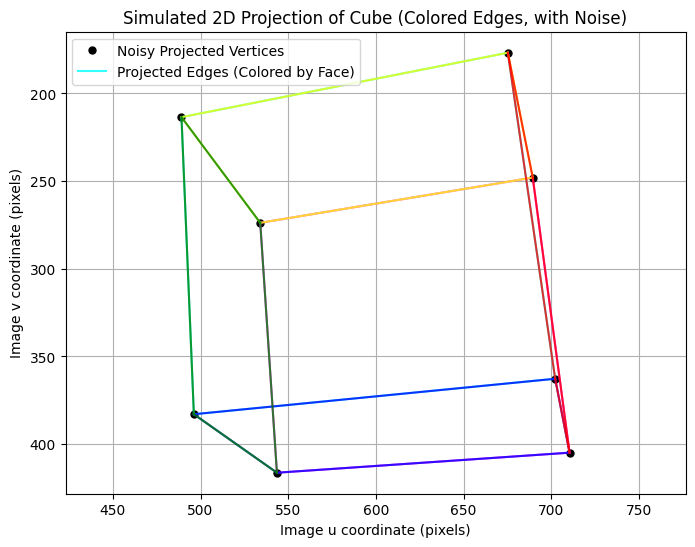

In [29]:
plt.figure(figsize=(8, 6))
ax_2d = plt.gca()
ax_2d.plot(noisy_projected_points[:, 0], noisy_projected_points[:, 1], 'ko', markersize=5, label='Noisy Projected Vertices') # Black dots
edge_legend_added = False
for i, face in enumerate(faces):
    face_proj_points = noisy_projected_points[face]
    color = face_colors_plotly[i]
    for j in range(len(face)):
        start_point = face_proj_points[j]
        end_point = face_proj_points[(j + 1) % len(face)]
        line_label = 'Projected Edges (Colored by Face)' if not edge_legend_added else '_nolegend_'
        ax_2d.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]],
                   color=color, linestyle='-', linewidth=1.5, alpha=0.8, label=line_label)
        edge_legend_added = True
plt.title('Simulated 2D Projection of Cube (Colored Edges, with Noise)')
plt.xlabel('Image u coordinate (pixels)')
plt.ylabel('Image v coordinate (pixels)')
ax_2d.legend()
plt.grid(True)
plt.xlim(0, img_width)
plt.ylim(0, img_height)
plt.gca().invert_yaxis()
plt.axis('equal')
plt.show()

## 4.8 Parameters and Point Table

In [28]:
print("\n--- Ground Truth Camera Parameters ---")
print("Intrinsics (K):")
print(K)
print("\nRotation (R):")
print(R)
print("\nTranslation (t):")
print(t)
print(f"\nCalculated Camera Center (World Coords): [{cam_center[0]:.2f}, {cam_center[1]:.2f}, {cam_center[2]:.2f}]")
print("\n--- World 3D Points and Projected 2D Points (with Noise) ---")
print("World (X, Y, Z)    |  Noisy Image (u, v)  |  Proj. 3D (World X, Y, Z)")
print("--------------------------------------------------------------------------")
for i in range(len(world_points_3d)):
    wp = world_points_3d[i]
    ip = noisy_projected_points[i]
    ppw = points_on_plane_world[i]
    print(f"({wp[0]:4.1f}, {wp[1]:4.1f}, {wp[2]:4.1f})   | ({ip[0]:6.1f}, {ip[1]:6.1f})  |  ({ppw[0]:6.2f}, {ppw[1]:6.2f}, {ppw[2]:6.2f})")


--- Ground Truth Camera Parameters ---
Intrinsics (K):
[[700.   0. 400.]
 [  0. 700. 300.]
 [  0.   0.   1.]]

Rotation (R):
[[ 0.90630776  0.          0.42261827]
 [-0.14454395  0.9396926   0.3099755 ]
 [-0.39713126 -0.34202012  0.8516507 ]]

Translation (t):
[[ 0.5]
 [-0.5]
 [ 4. ]]

Calculated Camera Center (World Coords): [1.06, 1.84, -3.46]

--- World 3D Points and Projected 2D Points (with Noise) ---
World (X, Y, Z)    |  Noisy Image (u, v)  |  Proj. 3D (World X, Y, Z)
--------------------------------------------------------------------------
( 0.0,  0.0,  0.0)   | ( 489.1,  213.5)  |  (  0.80,   1.38,  -2.60)
( 1.0,  0.0,  0.0)   | ( 675.3,  176.8)  |  (  1.05,   1.33,  -2.50)
( 1.0,  1.0,  0.0)   | ( 702.3,  362.7)  |  (  1.04,   1.58,  -2.40)
( 0.0,  1.0,  0.0)   | ( 496.2,  383.0)  |  (  0.77,   1.61,  -2.52)
( 0.0,  0.0,  1.0)   | ( 534.1,  273.8)  |  (  0.84,   1.46,  -2.54)
( 1.0,  0.0,  1.0)   | ( 689.5,  248.0)  |  (  1.05,   1.43,  -2.46)
( 1.0,  1.0,  1.0)   | ( 710.5